# COMPASS-SVP: Active-Reflective (AR) Dimension Benchmark, Prototype Optimization, and t-SNE Visualization

## 1. Elbow Method Optimization for Optimal Prototype Number (K) Selection (Active-Reflective Dimension)

Extracting WCSS values for AR dimension across LOSO iterations...


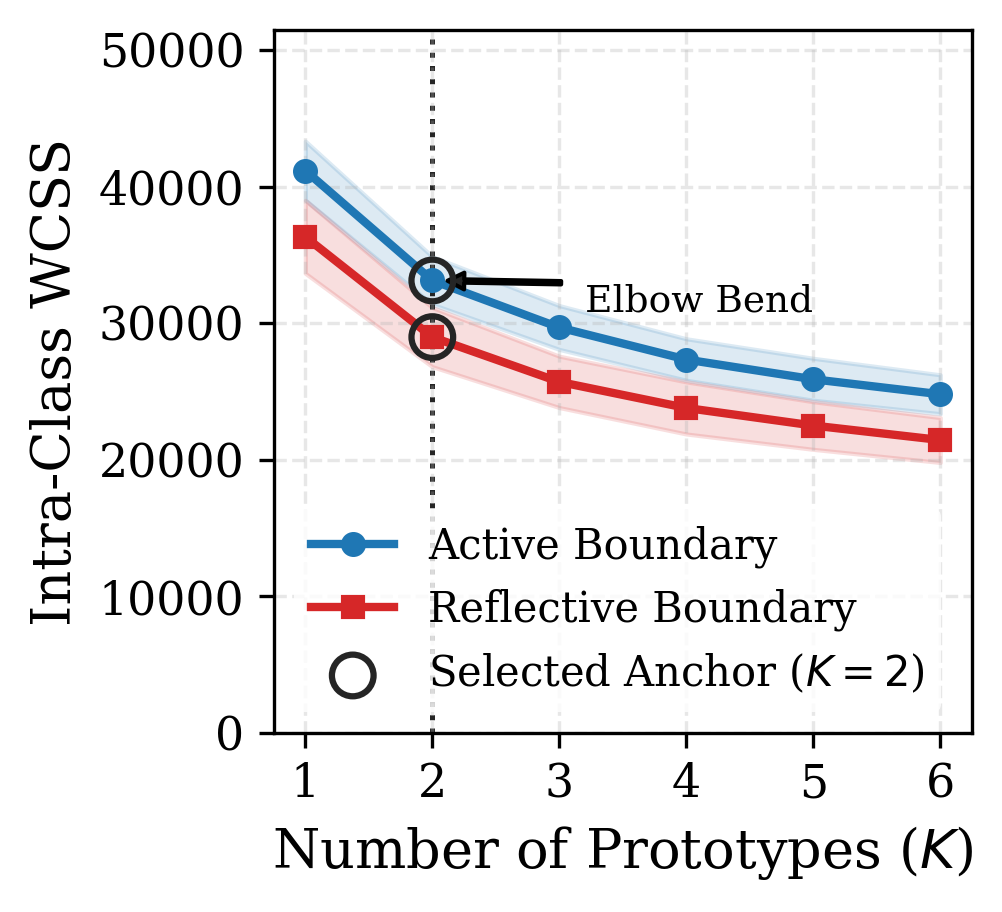

[SUCCESS] Publication-ready plot exported to: fig6_wcss_convergence_ar.png


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PLOT STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 13
})

file_input = "combined_fe_plv_ar.csv"
FIXED_SEED = 42
max_k = 6

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())
    
    wcss_matrix_c0 = []
    wcss_matrix_c1 = []
    
    print("Extracting WCSS values for AR dimension across LOSO iterations...")
    
    for test_subj in subjects:
        df_train = df[df["subject"] != test_subj].copy()
        
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
        X_train = df_train[feature_cols].values
        y_train = df_train["y"].values
        
        svm_filter = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
        svm_filter.fit(X_train, y_train)
        
        sv_features = svm_filter.support_vectors_
        sv_labels = y_train[svm_filter.support_]
        
        fold_wcss_c0 = []
        fold_wcss_c1 = []
        
        for k in range(1, max_k + 1):
            X_sv_c0 = sv_features[sv_labels == 0]
            kmeans_c0 = KMeans(n_clusters=k, n_init='auto', random_state=FIXED_SEED)
            kmeans_c0.fit(X_sv_c0)
            fold_wcss_c0.append(kmeans_c0.inertia_)
            
            X_sv_c1 = sv_features[sv_labels == 1]
            kmeans_c1 = KMeans(n_clusters=k, n_init='auto', random_state=FIXED_SEED)
            kmeans_c1.fit(X_sv_c1)
            fold_wcss_c1.append(kmeans_c1.inertia_)
            
        wcss_matrix_c0.append(fold_wcss_c0)
        wcss_matrix_c1.append(fold_wcss_c1)
        
    avg_wcss_c0 = np.mean(wcss_matrix_c0, axis=0)
    std_wcss_c0 = np.std(wcss_matrix_c0, axis=0)
    
    avg_wcss_c1 = np.mean(wcss_matrix_c1, axis=0)
    std_wcss_c1 = np.std(wcss_matrix_c1, axis=0)
    
    k_values = np.arange(1, max_k + 1)
    
    # ==========================================
    # 2. WCSS CONVERGENCE PLOTTING & EXPORT
    # ==========================================
    fig, ax = plt.subplots(figsize=(3.5, 3.2), dpi=300)
    
    ax.plot(k_values, avg_wcss_c0, marker='o', markersize=5, linewidth=2.0, color='#1f77b4', label='Active Boundary')
    ax.fill_between(k_values, avg_wcss_c0 - std_wcss_c0, avg_wcss_c0 + std_wcss_c0, color='#1f77b4', alpha=0.15)
    
    ax.plot(k_values, avg_wcss_c1, marker='s', markersize=5, linewidth=2.0, color='#d62728', label='Reflective Boundary')
    ax.fill_between(k_values, avg_wcss_c1 - std_wcss_c1, avg_wcss_c1 + std_wcss_c1, color='#d62728', alpha=0.15)
    
    ax.axvline(x=2, color='#252525', linestyle=':', linewidth=1.2, zorder=1)
    ax.scatter([2, 2], [avg_wcss_c0[1], avg_wcss_c1[1]], color='none', edgecolors='#252525', 
               s=100, linewidths=1.5, zorder=6, label='Selected Anchor ($K=2$)')
    
    ax.annotate('Elbow Bend', xy=(2, max(avg_wcss_c0[1], avg_wcss_c1[1])), 
                xytext=(3.2, max(avg_wcss_c0[0], avg_wcss_c1[0])*0.75),
                arrowprops=dict(facecolor='#252525', shrink=0.1, width=0.8, headwidth=4, headlength=4),
                fontsize=9, fontfamily='serif')
    
    ax.set_xlabel("Number of Prototypes ($K$)")
    ax.set_ylabel("Intra-Class WCSS")
    ax.set_xticks(k_values)
    ax.set_ylim(bottom=0, top=max(avg_wcss_c0[0], avg_wcss_c1[0]) * 1.25)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', framealpha=0.8)
    
    plt.tight_layout()
    output_name = "fig6_wcss_convergence_ar.png"
    plt.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Publication-ready plot exported to: {output_name}")

## 2. Hierarchical Classification Evaluation and Benchmark Summary (Active-Reflective Dimension)

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_ar.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2  

models_to_evaluate = [
    ("COMPASS-SVP (Cosine)", "compass", "cosine"),
    ("SVM (Baseline)", "standard", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)),
    ("Random Forest (Baseline)", "standard", RandomForestClassifier(n_estimators=100, random_state=FIXED_SEED)),
    ("MLP (Baseline)", "standard", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=FIXED_SEED)),
    ("KNN (Baseline)", "standard", KNeighborsClassifier(n_neighbors=5)),
    ("COMPASS-SVP (Euclidean)", "compass", "euclidean")
]

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    # Mapping labels to English
    df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    
    # Sort subjects numerically to keep strict ascending order
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))
    
    global_summary = {}

    for item in models_to_evaluate:
        model_name = item[0]
        model_type = item[1]
        
        print(f"\n" + "#"*115)
        print(f" EVALUATION & DETAILED REPORT: {model_name} (Active-Reflective Dimension) ")
        print("#"*115)
        
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []

        # ==========================================
        # 2. STRICT LOSO (LEAVE-ONE-SUBJECT-OUT)
        # ==========================================
        for test_subj in subjects:
            set_seed(FIXED_SEED)
            df_train = df[df["subject"] != test_subj].copy()
            df_test  = df[df["subject"] == test_subj].copy()
            
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

            X_train, y_train = df_train[feature_cols].values, df_train["y"].values
            X_test, y_test   = df_test[feature_cols].values, df_test["y"].values
            
            if model_type == "compass":
                dist_metric = item[2]
                extractor = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
                extractor.fit(X_train, y_train)
                
                if hasattr(extractor, "support_vectors_"):
                    sv_features = extractor.support_vectors_
                    sv_labels = y_train[extractor.support_]
                else:
                    sv_features = X_train
                    sv_labels = y_train
                
                prototypes = []
                proto_labels = []
                
                for label_val in [0, 1]:
                    X_sv_class = sv_features[sv_labels == label_val]
                    current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
                    
                    set_seed(FIXED_SEED)
                    kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
                    kmeans.fit(X_sv_class)
                    
                    prototypes.append(kmeans.cluster_centers_)
                    proto_labels.append(np.full(current_k, label_val))
                    
                all_prototypes = np.vstack(prototypes)
                all_proto_labels = np.concatenate(proto_labels)
                
                distances = cdist(X_test, all_prototypes, metric=dist_metric)
                y_test_pred = all_proto_labels[np.argmin(distances, axis=1)]
            else:
                clf = item[2]
                clf.fit(X_train, y_train)
                y_test_pred = clf.predict(X_test)
            
            df_test["y_pred"] = y_test_pred
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            # --- WINDOW TO TRIAL MAJORITY VOTING ---
            subj_trial_true, subj_trial_pred = [], []
            
            # Sort trials numerically for each subject
            sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
            
            for trial_id in sorted_trials:
                g = df_test[df_test["trial"] == trial_id]
                t_true = "active" if g["y"].iloc[0] == 0 else "reflective"
                
                active_votes = (g["y_pred"] == 0).sum()
                refl_votes = (g["y_pred"] == 1).sum()
                
                pred_trial_idx = 0 if active_votes > refl_votes else 1
                pred_trial_str = "active" if pred_trial_idx == 0 else "reflective"
                
                all_trial_pred.append(pred_trial_idx)
                all_trial_true.append(g["y"].iloc[0])
                
                subj_trial_pred.append(pred_trial_idx)
                subj_trial_true.append(g["y"].iloc[0])
                
                status_trial = "correct" if pred_trial_str == t_true else "incorrect"
                
                trial_records.append({
                    "subject": int(test_subj),
                    "trial": int(trial_id),
                    "True_Class": t_true,
                    "Majority": pred_trial_str,
                    "active_Votes": int(active_votes),
                    "reflective_Votes": int(refl_votes),
                    "Status": status_trial
                })

            # --- TRIAL TO SUBJECT MAJORITY VOTING ---
            s_true = "active" if df_test["y"].iloc[0] == 0 else "reflective"
            
            active_trials_count = sum(1 for p in subj_trial_pred if p == 0)
            refl_trials_count = sum(1 for p in subj_trial_pred if p == 1)
            
            subj_pred_idx = 0 if active_trials_count >= refl_trials_count else 1
            subj_pred_str = "active" if subj_pred_idx == 0 else "reflective"
            
            all_subj_true.append(df_test["y"].iloc[0])
            all_subj_pred.append(subj_pred_idx)
            
            status_subj = "correct" if subj_pred_str == s_true else "incorrect"
            
            subject_records.append({
                "subject": int(test_subj),
                "True_Class": s_true,
                "Majority": subj_pred_str,
                "active_Trials": int(active_trials_count),
                "reflective_Trials": int(refl_trials_count),
                "Status": status_subj
            })

            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

        # ==========================================
        # 3. PRINT DETAILED REPORTS (IN ENGLISH)
        # ==========================================
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
        win_acc = accuracy_score(all_win_true, all_win_pred)
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=["active", "reflective"], digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        
        t_acc = accuracy_score(all_trial_true, all_trial_pred)
        t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        
        print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
        print(f"Trial-Level Precision : {t_prec:.4f}")
        print(f"Trial-Level Recall    : {t_rec:.4f}")
        print(f"Trial-Level F1-Score  : {t_f1:.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        s_acc = accuracy_score(all_subj_true, all_subj_pred)
        s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
        print("-" * 65)
        print(f"Accuracy  : {s_acc*100:.2f}%")
        print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
        print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
        print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               Active  Reflective")
        print(f"Active      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"Reflective  :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

        global_summary[model_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(t_acc * 100, 2),
            "Subj Acc (%)": round(s_acc * 100, 2),
            "Subj Prec (%)": round(s_prec * 100, 2),
            "Subj Rec (%)": round(s_rec * 100, 2),
            "Subj F1 (%)": round(s_f1 * 100, 2)
        }

    # ==========================================
    # 4. FINAL SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(f" FINAL BENCHMARK SUMMARY: ACTIVE-REFLECTIVE (AR) DIMENSION ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)


###################################################################################################################
 EVALUATION & DETAILED REPORT: COMPASS-SVP (Cosine) (Active-Reflective Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 39.00% | Trial Acc: 25.00% | Status: INCORRECT
Subject 02 | Win Acc: 40.33% | Trial Acc: 40.00% | Status: INCORRECT
Subject 03 | Win Acc: 49.67% | Trial Acc: 45.00% | Status: INCORRECT
Subject 04 | Win Acc: 63.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 05 | Win Acc: 57.67% | Trial Acc: 70.00% | Status: CORRECT
Subject 06 | Win Acc: 46.00% | Trial Acc: 50.00% | Status: CORRECT
Subject 07 | Win Acc: 73.00% | Trial Acc: 85.00% | Status: CORRECT
Subject 08 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 09 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 10 | Win Acc: 46.33% | Trial Acc: 45.00% | Status: INCORRECT
Subjec

In [1]:
import os
import random
import warnings
from scipy.spatial.distance import cdist
from scipy.stats import binomtest
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")


def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)


# ==========================================
# STATISTICAL RIGOR EVALUATION FUNCTION
# ==========================================
def evaluate_subject_statistics(
    y_true,
    y_pred_model1,
    y_pred_model2,
    model_name1="COMPASS-SVP (Cosine)",
    model_name2="SVM (Baseline)",
):
  n_subj = len(y_true)
  corr1 = np.sum(y_true == y_pred_model1)
  corr2 = np.sum(y_true == y_pred_model2)

  ci1 = binomtest(corr1, n=n_subj).proportion_ci(
      confidence_level=0.95, method="exact"
  )
  ci2 = binomtest(corr2, n=n_subj).proportion_ci(
      confidence_level=0.95, method="exact"
  )

  print(f"\n=== STATISTICAL RIGOR COMPARISON (n = {n_subj} independent subjects) ===")
  print(
      f"[{model_name1}] Accuracy: {corr1/n_subj*100:.1f}% ({corr1}/{n_subj}) |"
      f" 95% Exact CI: [{ci1.low*100:.1f}%, {ci1.high*100:.1f}%]"
  )
  print(
      f"[{model_name2}] Accuracy: {corr2/n_subj*100:.1f}% ({corr2}/{n_subj}) |"
      f" 95% Exact CI: [{ci2.low*100:.1f}%, {ci2.high*100:.1f}%]"
  )

  only_m1 = np.sum((y_pred_model1 == y_true) & (y_pred_model2 != y_true))
  only_m2 = np.sum((y_pred_model1 != y_true) & (y_pred_model2 == y_true))
  n_disc = only_m1 + only_m2
  p_mcnemar = (
      min(1.0, 2 * binomtest(min(only_m1, only_m2), n=n_disc, p=0.5).pvalue)
      if n_disc > 0
      else 1.0
  )
  print(f"Exact McNemar Test p-value: {p_mcnemar:.4f}")

  diff_observed = np.mean(y_pred_model1 == y_true) - np.mean(
      y_pred_model2 == y_true
  )
  n_perms = 10000
  diff_perm = []
  paired_data = np.array(
      list(zip(y_pred_model1 == y_true, y_pred_model2 == y_true))
  )
  np.random.seed(42)
  for _ in range(n_perms):
    perm_m1 = paired_data[:, 0].copy()
    perm_m2 = paired_data[:, 1].copy()
    swap_mask = np.random.rand(n_subj) > 0.5
    temp = perm_m1[swap_mask].copy()
    perm_m1[swap_mask] = perm_m2[swap_mask]
    perm_m2[swap_mask] = temp
    diff_perm.append(np.mean(perm_m1) - np.mean(perm_m2))

  p_perm = np.mean(np.abs(diff_perm) >= np.abs(diff_observed))
  print(
      f"Observed Accuracy Delta: {diff_observed*100:+.1f}% | Paired Permutation"
      f" Test p-value: {p_perm:.4f}\n"
  )


# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_ar.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2

models_to_evaluate = [
    ("COMPASS-SVP (Cosine)", "compass", "cosine"),
    (
        "SVM (Baseline)",
        "standard",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            random_state=FIXED_SEED,
        ),
    ),
    (
        "Random Forest (Baseline)",
        "standard",
        RandomForestClassifier(n_estimators=100, random_state=FIXED_SEED),
    ),
    (
        "MLP (Baseline)",
        "standard",
        MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=FIXED_SEED),
    ),
    ("KNN (Baseline)", "standard", KNeighborsClassifier(n_neighbors=5)),
    ("COMPASS-SVP (Euclidean)", "compass", "euclidean"),
]

if not os.path.exists(file_input):
  print(f"Error: File {file_input} not found!")
else:
  df = pd.read_csv(file_input)
  # Mapping labels to English
  df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
  feature_cols = [c for c in df.columns if "-" in c]

  # Sort subjects numerically to keep strict ascending order
  subjects = sorted(df["subject"].unique(), key=lambda x: int(x))

  global_summary = {}
  stored_subject_preds = (
      {}
  )  # Dictionary untuk menyimpan hasil prediksi subjek tiap model

  for item in models_to_evaluate:
    model_name = item[0]
    model_type = item[1]

    print(f"\n" + "#" * 115)
    print(
        f" EVALUATION & DETAILED REPORT: {model_name} (Active-Reflective"
        " Dimension) "
    )
    print("#" * 115)

    all_win_true, all_win_pred = [], []
    trial_records = []
    subject_records = []
    all_trial_true, all_trial_pred = [], []
    all_subj_true, all_subj_pred = [], []

    # ==========================================
    # 2. STRICT LOSO (LEAVE-ONE-SUBJECT-OUT)
    # ==========================================
    for test_subj in subjects:
      set_seed(FIXED_SEED)
      df_train = df[df["subject"] != test_subj].copy()
      df_test = df[df["subject"] == test_subj].copy()

      for s in df_train["subject"].unique():
        mask = df_train["subject"] == s
        scaler_tr = StandardScaler()
        df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(
            df_train.loc[mask, feature_cols]
        )

      scaler_te = StandardScaler()
      df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

      X_train, y_train = df_train[feature_cols].values, df_train["y"].values
      X_test, y_test = df_test[feature_cols].values, df_test["y"].values

      if model_type == "compass":
        dist_metric = item[2]
        extractor = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            random_state=FIXED_SEED,
        )
        extractor.fit(X_train, y_train)

        if hasattr(extractor, "support_vectors_"):
          sv_features = extractor.support_vectors_
          sv_labels = y_train[extractor.support_]
        else:
          sv_features = X_train
          sv_labels = y_train

        prototypes = []
        proto_labels = []

        for label_val in [0, 1]:
          X_sv_class = sv_features[sv_labels == label_val]
          current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))

          set_seed(FIXED_SEED)
          kmeans = KMeans(
              n_clusters=current_k, n_init="auto", random_state=FIXED_SEED
          )
          kmeans.fit(X_sv_class)

          prototypes.append(kmeans.cluster_centers_)
          proto_labels.append(np.full(current_k, label_val))

        all_prototypes = np.vstack(prototypes)
        all_proto_labels = np.concatenate(proto_labels)

        distances = cdist(X_test, all_prototypes, metric=dist_metric)
        y_test_pred = all_proto_labels[np.argmin(distances, axis=1)]
      else:
        clf = item[2]
        clf.fit(X_train, y_train)
        y_test_pred = clf.predict(X_test)

      df_test["y_pred"] = y_test_pred
      all_win_true.extend(y_test)
      all_win_pred.extend(y_test_pred)

      # --- WINDOW TO TRIAL MAJORITY VOTING ---
      subj_trial_true, subj_trial_pred = [], []
      sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))

      for trial_id in sorted_trials:
        g = df_test[df_test["trial"] == trial_id]
        t_true = "active" if g["y"].iloc[0] == 0 else "reflective"

        active_votes = (g["y_pred"] == 0).sum()
        refl_votes = (g["y_pred"] == 1).sum()

        pred_trial_idx = 0 if active_votes > refl_votes else 1
        pred_trial_str = "active" if pred_trial_idx == 0 else "reflective"

        all_trial_pred.append(pred_trial_idx)
        all_trial_true.append(g["y"].iloc[0])

        subj_trial_pred.append(pred_trial_idx)
        subj_trial_true.append(g["y"].iloc[0])

        status_trial = "correct" if pred_trial_str == t_true else "incorrect"

        trial_records.append({
            "subject": int(test_subj),
            "trial": int(trial_id),
            "True_Class": t_true,
            "Majority": pred_trial_str,
            "active_Votes": int(active_votes),
            "reflective_Votes": int(refl_votes),
            "Status": status_trial,
        })

      # --- TRIAL TO SUBJECT MAJORITY VOTING ---
      s_true = "active" if df_test["y"].iloc[0] == 0 else "reflective"

      active_trials_count = sum(1 for p in subj_trial_pred if p == 0)
      refl_trials_count = sum(1 for p in subj_trial_pred if p == 1)

      subj_pred_idx = 0 if active_trials_count >= refl_trials_count else 1
      subj_pred_str = "active" if subj_pred_idx == 0 else "reflective"

      all_subj_true.append(df_test["y"].iloc[0])
      all_subj_pred.append(subj_pred_idx)

      status_subj = "correct" if subj_pred_str == s_true else "incorrect"

      subject_records.append({
          "subject": int(test_subj),
          "True_Class": s_true,
          "Majority": subj_pred_str,
          "active_Trials": int(active_trials_count),
          "reflective_Trials": int(refl_trials_count),
          "Status": status_subj,
      })

      subj_win_acc = accuracy_score(y_test, y_test_pred)
      subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
      print(
          f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% |"
          f" Trial Acc: {subj_trial_acc*100:.2f}% | Status:"
          f" {status_subj.upper()}"
      )

    # Simpan hasil prediksi subjek untuk uji statistik terpasang
    stored_subject_preds[model_name] = {
        "true": np.array(all_subj_true),
        "pred": np.array(all_subj_pred),
    }

    # ==========================================
    # 3. PRINT DETAILED REPORTS (IN ENGLISH)
    # ==========================================
    print(
        "\n=================================== WINDOW-LEVEL PERFORMANCE"
        f" ({model_name}) ==================================="
    )
    win_acc = accuracy_score(all_win_true, all_win_pred)
    print(f"Global Accuracy: {win_acc:.4f}")
    print(
        classification_report(
            all_win_true,
            all_win_pred,
            target_names=["active", "reflective"],
            digits=4,
        )
    )

    df_trials_out = pd.DataFrame(trial_records)
    print(
        "=================================== TRIAL-LEVEL PERFORMANCE"
        f" ({model_name}) ==================================="
    )
    print(df_trials_out.to_string(index=False))

    t_acc = accuracy_score(all_trial_true, all_trial_pred)
    t_prec = precision_score(
        all_trial_true, all_trial_pred, average="macro", zero_division=0
    )
    t_rec = recall_score(
        all_trial_true, all_trial_pred, average="macro", zero_division=0
    )
    t_f1 = f1_score(
        all_trial_true, all_trial_pred, average="macro", zero_division=0
    )

    print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
    print(f"Trial-Level Precision : {t_prec:.4f}")
    print(f"Trial-Level Recall    : {t_rec:.4f}")
    print(f"Trial-Level F1-Score  : {t_f1:.4f}")

    df_subs_out = pd.DataFrame(subject_records)
    print(
        "=================================== SUBJECT-LEVEL PERFORMANCE"
        f" ({model_name}) ==================================="
    )
    print(df_subs_out.to_string(index=False))

    s_acc = accuracy_score(all_subj_true, all_subj_pred)
    s_prec = precision_score(
        all_subj_true, all_subj_pred, average="macro", zero_division=0
    )
    s_rec = recall_score(
        all_subj_true, all_subj_pred, average="macro", zero_division=0
    )
    s_f1 = f1_score(
        all_subj_true, all_subj_pred, average="macro", zero_division=0
    )
    cm_subj = confusion_matrix(all_subj_true, all_subj_pred)

    print("-" * 65)
    print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
    print("-" * 65)
    print(f"Accuracy  : {s_acc*100:.2f}%")
    print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
    print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
    print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
    print("-" * 65)
    print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
    print(f"               Active  Reflective")
    print(f"Active      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
    print(f"Reflective  :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
    print("-" * 65)

    global_summary[model_name] = {
        "Win Acc (%)": round(win_acc * 100, 2),
        "Trial Acc (%)": round(t_acc * 100, 2),
        "Subj Acc (%)": round(s_acc * 100, 2),
        "Subj Prec (%)": round(s_prec * 100, 2),
        "Subj Rec (%)": round(s_rec * 100, 2),
        "Subj F1 (%)": round(s_f1 * 100, 2),
    }

  # ==========================================
  # 4. FINAL SUMMARY TABLE
  # ==========================================
  print("\n" + "=" * 125)
  print(f" FINAL BENCHMARK SUMMARY: ACTIVE-REFLECTIVE (AR) DIMENSION ")
  print("=" * 125)
  df_results = pd.DataFrame(global_summary).T
  print(df_results.to_string())
  print("=" * 125)

  # ==========================================
  # 5. AUTOMATED STATISTICAL RIGOR EVALUATION
  # ==========================================
  base_key = "SVM (Baseline)"
  if base_key in stored_subject_preds:
    y_true_s = stored_subject_preds[base_key]["true"]
    y_pred_base = stored_subject_preds[base_key]["pred"]

    for comp_model in ["COMPASS-SVP (Cosine)", "COMPASS-SVP (Euclidean)"]:
      if comp_model in stored_subject_preds:
        y_pred_comp = stored_subject_preds[comp_model]["pred"]
        evaluate_subject_statistics(
            y_true_s,
            y_pred_comp,
            y_pred_base,
            model_name1=comp_model,
            model_name2=base_key,
        )


###################################################################################################################
 EVALUATION & DETAILED REPORT: COMPASS-SVP (Cosine) (Active-Reflective Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 39.00% | Trial Acc: 25.00% | Status: INCORRECT
Subject 02 | Win Acc: 40.33% | Trial Acc: 40.00% | Status: INCORRECT
Subject 03 | Win Acc: 49.67% | Trial Acc: 45.00% | Status: INCORRECT
Subject 04 | Win Acc: 63.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 05 | Win Acc: 57.67% | Trial Acc: 70.00% | Status: CORRECT
Subject 06 | Win Acc: 46.00% | Trial Acc: 50.00% | Status: CORRECT
Subject 07 | Win Acc: 73.00% | Trial Acc: 85.00% | Status: CORRECT
Subject 08 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 09 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 10 | Win Acc: 46.33% | Trial Acc: 45.00% | Status: INCORRECT
Subjec

## 3. t-SNE Latent Space Manifold Projection and Geometric Decision Boundary Visualization

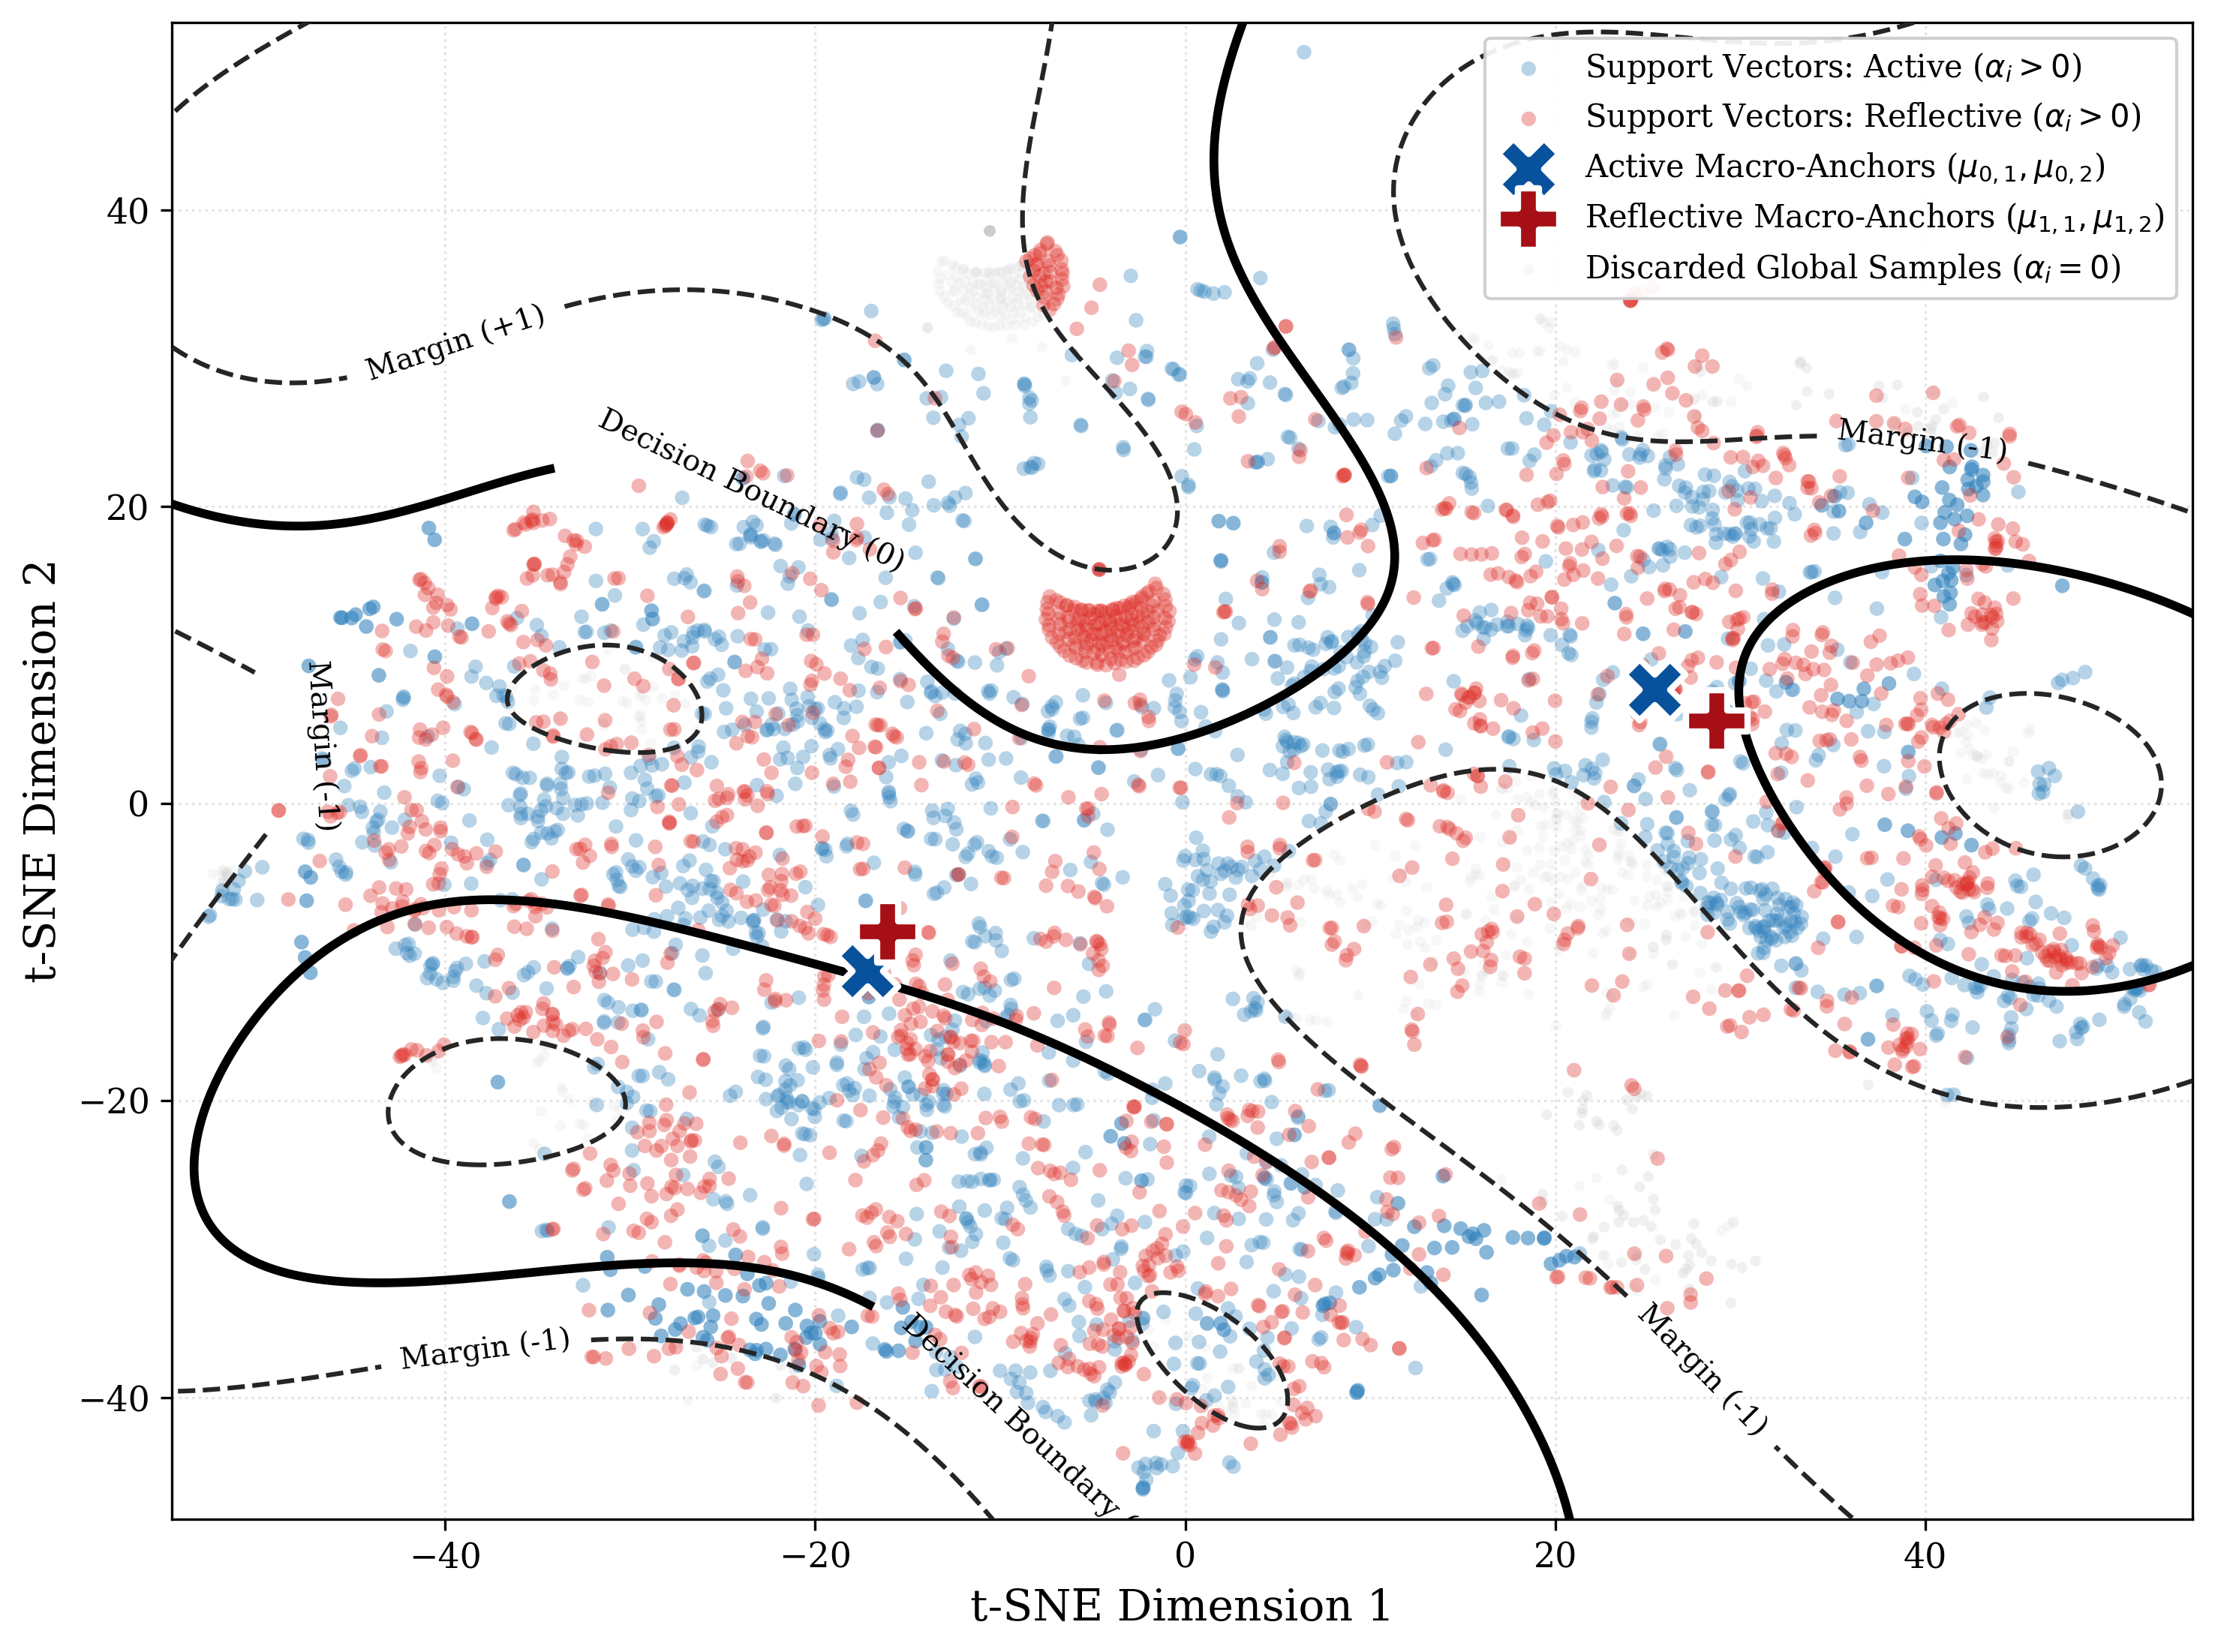

[SUCCESS] Optimized C=1.0 decision boundary plot successfully exported to: fig4_real_decision_boundary_ar_tsne_c1.png


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PLOT STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 14
})

file_input = "combined_fe_plv_ar.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2 

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique())
    
    # LOSO simulation for visualization
    visualize_test_subj = subjects[-1]
    df_train = df[df["subject"] != visualize_test_subj].copy()
    
    for s in df_train["subject"].unique():
        mask = df_train["subject"] == s
        scaler_tr = StandardScaler()
        df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
    X_train = df_train[feature_cols].values
    y_train = df_train["y"].values
    
    # ==========================================
    # t-SNE OPTIMIZATION: PERPLEXITY SET TO 50
    # ==========================================
    tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto', 
                init='pca', random_state=FIXED_SEED)
    X_tsne_train = tsne.fit_transform(X_train)
    
    # ==========================================
    # 2. SVM MODELING WITH NATIVE C = 1.0
    # ==========================================
    extractor = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
    extractor.fit(X_tsne_train, y_train)
    
    sv_features = extractor.support_vectors_
    sv_labels = y_train[extractor.support_]
    
    all_indices = np.arange(len(X_tsne_train))
    discarded_indices = np.setdiff1d(all_indices, extractor.support_)
    X_tsne_discarded = X_tsne_train[discarded_indices]
    y_tsne_discarded = y_train[discarded_indices]
    
    # K-Means Condensation
    prototypes = []
    for label_val in [0, 1]:
        X_sv_class = sv_features[sv_labels == label_val]
        current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
        kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
        kmeans.fit(X_sv_class)
        prototypes.append(kmeans.cluster_centers_)
        
    X_tsne_proto = np.vstack(prototypes)
    
    # Meshgrid Resolution
    ax_min_x, ax_max_x = X_tsne_train[:, 0].min() - 3, X_tsne_train[:, 0].max() + 3
    ax_min_y, ax_max_y = X_tsne_train[:, 1].min() - 3, X_tsne_train[:, 1].max() + 3
    xx, yy = np.meshgrid(np.linspace(ax_min_x, ax_max_x, 600),
                         np.linspace(ax_min_y, ax_max_y, 600))
    
    Z = extractor.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # ==========================================
    # 3. PLOTTING WITH STRICT VISUAL HIERARCHY
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 7.5), dpi=300)
    
    # Layer 1: Discarded Samples (Background & highly transparent)
    ax.scatter(X_tsne_discarded[:, 0], X_tsne_discarded[:, 1], c='#cccccc', 
               s=12, alpha=0.15, edgecolors='none', 
               label='Discarded Global Samples ($\\alpha_i = 0$)', zorder=1)
    
    # Layer 2: Support Vectors (Configured with alpha=0.35 & s=22)
    mask_c0 = sv_labels == 0
    mask_c1 = sv_labels == 1
    ax.scatter(sv_features[mask_c0, 0], sv_features[mask_c0, 1], c='#3182bd', s=22,
               alpha=0.35, edgecolors='none', label='Support Vectors: Active ($\\alpha_i > 0$)', zorder=2)
    ax.scatter(sv_features[mask_c1, 0], sv_features[mask_c1, 1], c='#de2d26', s=22,
               alpha=0.35, edgecolors='none', label='Support Vectors: Reflective ($\\alpha_i > 0$)', zorder=2)
    
    # Layer 3: Decision Boundary & Margins (Thickened & High Z-order)
    contour = ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['#252525', '#000000', '#252525'],
                         linestyles=['--', '-', '--'], linewidths=[1.5, 2.8, 1.5], zorder=4)
    ax.clabel(contour, inline=True, fmt={-1: 'Margin (-1)', 0: 'Decision Boundary (0)', 1: 'Margin (+1)'}, 
              fontsize=9.5, colors='#000000')
    
    # Layer 4: Macro-Anchors / Prototypes (Foreground, high contrast & distinct)
    ax.scatter(X_tsne_proto[:2, 0], X_tsne_proto[:2, 1], c='#08519c', marker='X', s=380, 
               edgecolors='white', linewidth=2.0, zorder=10, label='Active Macro-Anchors ($\\mu_{0,1}, \\mu_{0,2}$)')
    ax.scatter(X_tsne_proto[2:, 0], X_tsne_proto[2:, 1], c='#a50f15', marker='P', s=380, 
               edgecolors='white', linewidth=2.0, zorder=10, label='Reflective Macro-Anchors ($\\mu_{1,1}, \\mu_{1,2}$)')
    
    # Visual Parameterization
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.set_xlim(ax_min_x + 1, ax_max_x - 1)
    ax.set_ylim(ax_min_y + 1, ax_max_y - 1)
    ax.grid(True, linestyle=':', alpha=0.35)
    
    # Legend Placement
    handles, labels = ax.get_legend_handles_labels()
    legend_order = [1, 2, 3, 4, 0]
    ax.legend([handles[idx] for idx in legend_order], [labels[idx] for idx in legend_order], 
              loc='upper right', frameon=True, facecolor='white', framealpha=0.92, edgecolor='#cccccc')
    
    plt.tight_layout()
    output_img_name = "fig4_real_decision_boundary_ar_tsne_c1.png"
    plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Optimized C=1.0 decision boundary plot successfully exported to: {output_img_name}")

## 4. Component-Wise Ablation Study for COMPASS-SVP Framework Validation (Active-Reflective Dimension)

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_ar.csv"
FIXED_SEED = 42
K_PROTOTYPES_PER_CLASS = 2  

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    # Mapping labels to English
    df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))
    
    # Model variants for ablation study
    classifiers_pool = {
        "COMPASS-SVP (Full System)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "COMPASS-SVP (Scenario A: w/o K-Means)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "COMPASS-SVP (Scenario B: w/o SVM Sifting)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED),
        "SVM (Baseline)": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight='balanced', random_state=FIXED_SEED)
    }

    global_summary = {}

    # ==========================================
    # 2. CLASSIFICATION & ABLATION LOOP
    # ==========================================
    for model_name, extractor in classifiers_pool.items():
        header_title = f" EVALUATION & DETAILED REPORT: {model_name} (Active-Reflective Dimension) "
        print("\n" + "#" * 115)
        print(header_title)
        print("#" * 115)
        
        is_compass_full = model_name.startswith("COMPASS-SVP (Full")
        is_abl_a = "Scenario A" in model_name  # Without K-Means (Uses all raw support vectors)
        is_abl_b = "Scenario B" in model_name  # Without SVM Sifting (K-Means directly from all X_train)
        is_compass_any = is_compass_full or is_abl_a or is_abl_b
        
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []

        # ==========================================
        # 3. STRICT LOSO LOOP 
        # ==========================================
        for test_subj in subjects:
            set_seed(FIXED_SEED)
            df_train = df[df["subject"] != int(test_subj)].copy()
            df_test  = df[df["subject"] == int(test_subj)].copy()
            
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

            X_train, y_train = df_train[feature_cols].values, df_train["y"].values
            X_test, y_test   = df_test[feature_cols].values, df_test["y"].values
            
            extractor.fit(X_train, y_train)
            
            if is_compass_any:
                if is_abl_b:
                    # Scenario B: Skip SVM sifting, directly use entire training data
                    sv_features = X_train
                    sv_labels = y_train
                else:
                    # Full System & Scenario A: Extract Support Vectors from SVM
                    if hasattr(extractor, "support_vectors_"):
                        sv_features = extractor.support_vectors_
                        sv_labels = y_train[extractor.support_]
                    else:
                        sv_features = X_train
                        sv_labels = y_train
                
                prototypes = []
                proto_labels = []
                
                for label_val in [0, 1]:
                    X_sv_class = sv_features[sv_labels == label_val]
                    
                    if is_abl_a:
                        # Scenario A: Without K-Means, treat all support vectors as prototypes
                        prototypes.append(X_sv_class)
                        proto_labels.append(np.full(len(X_sv_class), label_val))
                    else:
                        # Full System & Scenario B: Run K-Means Clustering
                        current_k = min(K_PROTOTYPES_PER_CLASS, len(X_sv_class))
                        if current_k > 0:
                            set_seed(FIXED_SEED)
                            kmeans = KMeans(n_clusters=current_k, n_init='auto', random_state=FIXED_SEED)
                            kmeans.fit(X_sv_class)
                            prototypes.append(kmeans.cluster_centers_)
                            proto_labels.append(np.full(current_k, label_val))
                    
                all_prototypes = np.vstack(prototypes)
                all_proto_labels = np.concatenate(proto_labels)
                
                # Cosine distance computation for AR dimension
                distances = cdist(X_test, all_prototypes, metric='cosine')
                y_test_pred = all_proto_labels[np.argmin(distances, axis=1)]
            else:
                y_test_pred = extractor.predict(X_test)
            
            df_test["y_pred"] = y_test_pred
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            # --- WINDOW TO TRIAL MAJORITY VOTING ---
            subj_trial_true, subj_trial_pred = [], []
            
            # Sort trials numerically for each subject
            sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
            
            for trial_id in sorted_trials:
                g = df_test[df_test["trial"] == trial_id]
                t_true = "active" if g["y"].iloc[0] == 0 else "reflective"
                
                active_votes = int((g["y_pred"] == 0).sum())
                refl_votes = int((g["y_pred"] == 1).sum())
                
                pred_trial_idx = 0 if active_votes > refl_votes else 1
                pred_trial_str = "active" if pred_trial_idx == 0 else "reflective"
                
                all_trial_pred.append(pred_trial_idx)
                all_trial_true.append(g["y"].iloc[0])
                
                subj_trial_pred.append(pred_trial_idx)
                subj_trial_true.append(g["y"].iloc[0])
                
                status_trial = "correct" if pred_trial_str == t_true else "incorrect"
                
                trial_records.append({
                    "subject": int(test_subj),
                    "trial": int(trial_id),
                    "True_Class": t_true,
                    "Majority": pred_trial_str,
                    "active_Votes": active_votes,
                    "reflective_Votes": refl_votes,
                    "Status": status_trial
                })

            # --- TRIAL TO SUBJECT MAJORITY VOTING ---
            s_true = "active" if df_test["y"].iloc[0] == 0 else "reflective"
            
            active_trials_count = int(sum(1 for p in subj_trial_pred if p == 0))
            refl_trials_count = int(sum(1 for p in subj_trial_pred if p == 1))
            
            subj_pred_idx = 0 if active_trials_count >= refl_trials_count else 1
            subj_pred_str = "active" if subj_pred_idx == 0 else "reflective"
            
            all_subj_true.append(df_test["y"].iloc[0])
            all_subj_pred.append(subj_pred_idx)
            
            status_subj = "correct" if subj_pred_str == s_true else "incorrect"
            
            subject_records.append({
                "subject": int(test_subj),
                "True_Class": s_true,
                "Majority": subj_pred_str,
                "active_Trials": active_trials_count,
                "reflective_Trials": refl_trials_count,
                "Status": status_subj
            })

            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

        # ==========================================
        # 3. PRINT DETAILED REPORTS (IN ENGLISH)
        # ==========================================
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
        win_acc = accuracy_score(all_win_true, all_win_pred)
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=["active", "reflective"], digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        
        t_acc = accuracy_score(all_trial_true, all_trial_pred)
        t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        
        print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
        print(f"Trial-Level Precision : {t_prec:.4f}")
        print(f"Trial-Level Recall    : {t_rec:.4f}")
        print(f"Trial-Level F1-Score  : {t_f1:.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        s_acc = accuracy_score(all_subj_true, all_subj_pred)
        s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
        print("-" * 65)
        print(f"Accuracy  : {s_acc*100:.2f}%")
        print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
        print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
        print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               Active  Reflective")
        print(f"Active      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"Reflective  :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

        global_summary[model_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(t_acc * 100, 2),
            "Subj Acc (%)": round(s_acc * 100, 2),
            "Subj Prec (%)": round(s_prec * 100, 2),
            "Subj Rec (%)": round(s_rec * 100, 2),
            "Subj F1 (%)": round(s_f1 * 100, 2)
        }

    # ==========================================
    # 4. FINAL ABLATION SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(" COMPASS-SVP COMPONENT ABLATION STUDY RESULTS SUMMARY (DIMENSION: AR) ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)


###################################################################################################################
 EVALUATION & DETAILED REPORT: COMPASS-SVP (Full System) (Active-Reflective Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 39.00% | Trial Acc: 25.00% | Status: INCORRECT
Subject 02 | Win Acc: 40.33% | Trial Acc: 40.00% | Status: INCORRECT
Subject 03 | Win Acc: 49.67% | Trial Acc: 45.00% | Status: INCORRECT
Subject 04 | Win Acc: 63.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 05 | Win Acc: 57.67% | Trial Acc: 70.00% | Status: CORRECT
Subject 06 | Win Acc: 46.00% | Trial Acc: 50.00% | Status: CORRECT
Subject 07 | Win Acc: 73.00% | Trial Acc: 85.00% | Status: CORRECT
Subject 08 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 09 | Win Acc: 53.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 10 | Win Acc: 46.33% | Trial Acc: 45.00% | Status: INCORRECT
S

## 5. State-of-the-Art Comparative Benchmark: Adapted LSTM-CNN Architecture (Jawed et al., 2024)

In [3]:
import pandas as pd
import numpy as np
import os
import random

# --- LOCAL GPU HANDLING (Preventing Deadlock/Freeze in VS Code) ---
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 
# -------------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ==========================================
# 1. SEED & DATA CONFIGURATION
# ==========================================
FIXED_SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


file_input = "combined_fe_plv_ar.csv"  

# ==========================================
# 2. LSTM-CNN ARCHITECTURE DEFINITION (Adapted Jawed et al., 2024)
# ==========================================
def build_lstm_cnn_model(input_shape=(28, 1), num_classes=2):
    inputs = Input(shape=input_shape)
    
    # Layer 1: LSTM
    x = LSTM(64, return_sequences=True)(inputs) 
    
    # Layer 2: Conv1D (256 filters, kernel size 3)
    x = Conv1D(filters=256, kernel_size=3, padding='same', activation='relu')(x)
    
    # Layer 3: Dropout (20%)
    x = Dropout(0.20)(x)
    
    # Layer 4: MaxPooling1D (Pool size = 3)
    x = MaxPooling1D(pool_size=3, padding='same')(x)
    
    # Layer 5 & 6: Flatten & Dense (Softmax)
    x = Flatten()(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# ==========================================
# 3. MAIN WORKFLOW (LOSO + SCALING + HIERARCHICAL VOTING)
# ==========================================
if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic dimension detection based on filename
    if "ar" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
    else:
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))

    all_win_true, all_win_pred = [], []
    trial_records = []
    subject_records = []
    all_trial_true, all_trial_pred = [], []
    all_subj_true, all_subj_pred = [], []

    model_name = "Adapted LSTM-CNN (Jawed et al., 2024)"
    
    print("\n" + "#" * 115)
    print(f" EVALUATION & DETAILED REPORT: {model_name} ({dim_name} Dimension) ")
    print("#" * 115)

    for test_subj in subjects:
        K.clear_session()
        set_seed(FIXED_SEED)
        
        # Split Data (Leave-One-Subject-Out)
        df_train = df[df["subject"] != int(test_subj)].copy()
        df_test  = df[df["subject"] == int(test_subj)].copy()
        
        # Subject-wise StandardScaler on training data
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
        scaler_te = StandardScaler()
        df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])

        X_train = df_train[feature_cols].values.reshape(-1, len(feature_cols), 1)
        y_train = df_train["y"].values
        X_test = df_test[feature_cols].values.reshape(-1, len(feature_cols), 1)
        y_test = df_test["y"].values
        
        # Compute class weights to handle class imbalance
        classes_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = dict(enumerate(classes_weights))
        
        # --- A. TRAINING LSTM-CNN MODEL ---
        model = build_lstm_cnn_model(input_shape=(len(feature_cols), 1))
        model.fit(X_train, y_train, epochs=15, batch_size=16, class_weight=class_weight_dict, verbose=0) 
        
        # --- B. WINDOW-LEVEL TESTING ---
        y_pred_probs = model.predict(X_test, verbose=0)
        y_test_pred = np.argmax(y_pred_probs, axis=1)
        
        df_test["y_pred"] = y_test_pred
        all_win_true.extend(y_test)
        all_win_pred.extend(y_test_pred)
        
        # --- C. WINDOW TO TRIAL MAJORITY VOTING ---
        subj_trial_true, subj_trial_pred = [], []
        sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
        
        for trial_id in sorted_trials:
            g = df_test[df_test["trial"] == trial_id]
            t_true = "active" if g["y"].iloc[0] == 0 else "reflective"
            
            active_votes = int((g["y_pred"] == 0).sum())
            refl_votes = int((g["y_pred"] == 1).sum())
            
            pred_trial_idx = 0 if active_votes > refl_votes else 1
            pred_trial_str = "active" if pred_trial_idx == 0 else "reflective"
            
            all_trial_pred.append(pred_trial_idx)
            all_trial_true.append(g["y"].iloc[0])
            
            subj_trial_pred.append(pred_trial_idx)
            subj_trial_true.append(g["y"].iloc[0])
            
            status_trial = "correct" if pred_trial_str == t_true else "incorrect"
            
            trial_records.append({
                "subject": int(test_subj),
                "trial": int(trial_id),
                "True_Class": t_true,
                "Majority": pred_trial_str,
                "active_Votes": active_votes,
                "reflective_Votes": refl_votes,
                "Status": status_trial
            })

        # --- D. TRIAL TO SUBJECT MAJORITY VOTING ---
        s_true = "active" if df_test["y"].iloc[0] == 0 else "reflective"
        
        active_trials_count = int(sum(1 for p in subj_trial_pred if p == 0))
        refl_trials_count = int(sum(1 for p in subj_trial_pred if p == 1))
        
        subj_pred_idx = 0 if active_trials_count >= refl_trials_count else 1
        subj_pred_str = "active" if subj_pred_idx == 0 else "reflective"
        
        all_subj_true.append(df_test["y"].iloc[0])
        all_subj_pred.append(subj_pred_idx)
        
        status_subj = "correct" if subj_pred_str == s_true else "incorrect"
        
        subject_records.append({
            "subject": int(test_subj),
            "True_Class": s_true,
            "Majority": subj_pred_str,
            "active_Trials": active_trials_count,
            "reflective_Trials": refl_trials_count,
            "Status": status_subj
        })

        subj_win_acc = accuracy_score(y_test, y_test_pred)
        subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
        print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

    # ==========================================
    # 4. DETAILED REPORTS & EVALUATION METRICS
    # ==========================================
    print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
    win_acc = accuracy_score(all_win_true, all_win_pred)
    print(f"Global Accuracy: {win_acc:.4f}")
    print(classification_report(all_win_true, all_win_pred, target_names=["active", "reflective"], digits=4))
    
    df_trials_out = pd.DataFrame(trial_records)
    print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_trials_out.to_string(index=False))
    
    t_acc = accuracy_score(all_trial_true, all_trial_pred)
    t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    
    print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
    print(f"Trial-Level Precision : {t_prec:.4f}")
    print(f"Trial-Level Recall    : {t_rec:.4f}")
    print(f"Trial-Level F1-Score  : {t_f1:.4f}")

    df_subs_out = pd.DataFrame(subject_records)
    print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_subs_out.to_string(index=False))
    
    s_acc = accuracy_score(all_subj_true, all_subj_pred)
    s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
    
    print("-" * 65)
    print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
    print("-" * 65)
    print(f"Accuracy  : {s_acc*100:.2f}%")
    print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
    print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
    print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
    print("-" * 65)
    print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
    print(f"               Active  Reflective")
    print(f"Active      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
    print(f"Reflective  :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
    print("-" * 65)


###################################################################################################################
 EVALUATION & DETAILED REPORT: Adapted LSTM-CNN (Jawed et al., 2024) (Active-Reflective (AR) Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 47.33% | Trial Acc: 60.00% | Status: CORRECT
Subject 02 | Win Acc: 45.33% | Trial Acc: 35.00% | Status: INCORRECT
Subject 03 | Win Acc: 77.67% | Trial Acc: 100.00% | Status: CORRECT
Subject 04 | Win Acc: 24.67% | Trial Acc: 15.00% | Status: INCORRECT
Subject 05 | Win Acc: 17.67% | Trial Acc: 0.00% | Status: INCORRECT
Subject 06 | Win Acc: 61.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 07 | Win Acc: 22.67% | Trial Acc: 10.00% | Status: INCORRECT
Subject 08 | Win Acc: 64.67% | Trial Acc: 65.00% | Status: CORRECT
Subject 09 | Win Acc: 64.67% | Trial Acc: 65.00% | Status: CORRECT
Subject 10 | Win Acc: 75.67% | Trial Acc: 95.00% | 

## 6. State-of-the-Art Comparative Benchmark: ANOVA Feature Selection and Classical Machine Learning Framework (Yuvaraj et al., 2024)

In [4]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_ar.csv" # Change to your dataset (AR or VV)
FIXED_SEED = 42

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic label detection based on filename
    if "ar" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
    else:
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))

    # Initialize classifiers according to Yuvaraj et al. (2024)
    classifiers = {
        "Random Forest (RF)": RandomForestClassifier(n_estimators=100, random_state=FIXED_SEED),
        "K-Nearest Neighbor (KNN)": KNeighborsClassifier(n_neighbors=5),
        "Multilayer Perceptron (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=FIXED_SEED)
    }

    global_summary = {}

    # ==========================================
    # 2. CLASSIFICATION & EVALUATION LOOP
    # ==========================================
    for clf_name, clf in classifiers.items():
        header_title = f" EVALUATION & DETAILED REPORT: {clf_name} (Yuvaraj et al. Framework) "
        print("\n" + "#" * 115)
        print(header_title)
        print("#" * 115)
        
        all_win_true, all_win_pred = [], []
        trial_records = []
        subject_records = []
        all_trial_true, all_trial_pred = [], []
        all_subj_true, all_subj_pred = [], []

        # ==========================================
        # 3. STRICT LOSO (LEAVE-ONE-SUBJECT-OUT)
        # ==========================================
        for test_subj in subjects:
            set_seed(FIXED_SEED)
            df_train = df[df["subject"] != int(test_subj)].copy()
            df_test  = df[df["subject"] == int(test_subj)].copy()
            
            # Subject-wise StandardScaler on training data
            for s in df_train["subject"].unique():
                mask = df_train["subject"] == s
                scaler_tr = StandardScaler()
                df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
            
            scaler_te = StandardScaler()
            df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])
            
            X_train = df_train[feature_cols].values
            y_train = df_train["y"].values
            X_test = df_test[feature_cols].values
            y_test = df_test["y"].values
            
            # --- FEATURE SELECTION: ANOVA F-Value (Top 30 Percentile) ---
            selector = SelectPercentile(f_classif, percentile=30)
            X_train_selected = selector.fit_transform(X_train, y_train)
            X_test_selected = selector.transform(X_test)
            
            # --- TRAINING CLASSIFIER ---
            clf.fit(X_train_selected, y_train)
            
            # --- WINDOW-LEVEL TESTING ---
            y_test_pred = clf.predict(X_test_selected)
            df_test["y_pred"] = y_test_pred
            
            all_win_true.extend(y_test)
            all_win_pred.extend(y_test_pred)
            
            # --- WINDOW TO TRIAL MAJORITY VOTING ---
            subj_trial_true, subj_trial_pred = [], []
            sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
            
            for trial_id in sorted_trials:
                g = df_test[df_test["trial"] == trial_id]
                t_true = "active" if g["y"].iloc[0] == 0 else "reflective"
                
                active_votes = int((g["y_pred"] == 0).sum())
                refl_votes = int((g["y_pred"] == 1).sum())
                
                pred_trial_idx = 0 if active_votes >= refl_votes else 1
                pred_trial_str = "active" if pred_trial_idx == 0 else "reflective"
                
                all_trial_pred.append(pred_trial_idx)
                all_trial_true.append(g["y"].iloc[0])
                
                subj_trial_pred.append(pred_trial_idx)
                subj_trial_true.append(g["y"].iloc[0])
                
                status_trial = "correct" if pred_trial_str == t_true else "incorrect"
                
                trial_records.append({
                    "subject": int(test_subj),
                    "trial": int(trial_id),
                    "True_Class": t_true,
                    "Majority": pred_trial_str,
                    "active_Votes": active_votes,
                    "reflective_Votes": refl_votes,
                    "Status": status_trial
                })

            # --- TRIAL TO SUBJECT MAJORITY VOTING ---
            s_true = "active" if df_test["y"].iloc[0] == 0 else "reflective"
            
            active_trials_count = int(sum(1 for p in subj_trial_pred if p == 0))
            refl_trials_count = int(sum(1 for p in subj_trial_pred if p == 1))
            
            subj_pred_idx = 0 if active_trials_count > refl_trials_count else 1
            subj_pred_str = "active" if subj_pred_idx == 0 else "reflective"
            
            all_subj_true.append(df_test["y"].iloc[0])
            all_subj_pred.append(subj_pred_idx)
            
            status_subj = "correct" if subj_pred_str == s_true else "incorrect"
            
            subject_records.append({
                "subject": int(test_subj),
                "True_Class": s_true,
                "Majority": subj_pred_str,
                "active_Trials": active_trials_count,
                "reflective_Trials": refl_trials_count,
                "Status": status_subj
            })

            subj_win_acc = accuracy_score(y_test, y_test_pred)
            subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
            print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

        # ==========================================
        # 4. PRINT DETAILED REPORTS (IN ENGLISH)
        # ==========================================
        print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({clf_name}) ===================================")
        win_acc = accuracy_score(all_win_true, all_win_pred)
        print(f"Global Accuracy: {win_acc:.4f}")
        print(classification_report(all_win_true, all_win_pred, target_names=["active", "reflective"], digits=4))
        
        df_trials_out = pd.DataFrame(trial_records)
        print(f"=================================== TRIAL-LEVEL PERFORMANCE ({clf_name}) ===================================")
        print(df_trials_out.to_string(index=False))
        
        t_acc = accuracy_score(all_trial_true, all_trial_pred)
        t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
        
        print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
        print(f"Trial-Level Precision : {t_prec:.4f}")
        print(f"Trial-Level Recall    : {t_rec:.4f}")
        print(f"Trial-Level F1-Score  : {t_f1:.4f}")

        df_subs_out = pd.DataFrame(subject_records)
        print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({clf_name}) ===================================")
        print(df_subs_out.to_string(index=False))
        
        s_acc = accuracy_score(all_subj_true, all_subj_pred)
        s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
        cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
        
        print("-" * 65)
        print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({clf_name}):")
        print("-" * 65)
        print(f"Accuracy  : {s_acc*100:.2f}%")
        print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
        print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
        print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
        print("-" * 65)
        print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
        print(f"               Active  Reflective")
        print(f"Active      :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
        print(f"Reflective  :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
        print("-" * 65)

        global_summary[clf_name] = {
            "Win Acc (%)": round(win_acc * 100, 2),
            "Trial Acc (%)": round(t_acc * 100, 2),
            "Subj Acc (%)": round(s_acc * 100, 2),
            "Subj Prec (%)": round(s_prec * 100, 2),
            "Subj Rec (%)": round(s_rec * 100, 2),
            "Subj F1 (%)": round(s_f1 * 100, 2)
        }

    # ==========================================
    # 5. FINAL COMPARATIVE SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(f" FINAL BENCHMARK SUMMARY: YUVARAJ ET AL. (2024) FRAMEWORK [{dim_name}] ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)


###################################################################################################################
 EVALUATION & DETAILED REPORT: Random Forest (RF) (Yuvaraj et al. Framework) 
###################################################################################################################
Subject 01 | Win Acc: 46.33% | Trial Acc: 45.00% | Status: INCORRECT
Subject 02 | Win Acc: 61.00% | Trial Acc: 75.00% | Status: CORRECT
Subject 03 | Win Acc: 81.33% | Trial Acc: 100.00% | Status: CORRECT
Subject 04 | Win Acc: 63.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 05 | Win Acc: 34.00% | Trial Acc: 5.00% | Status: INCORRECT
Subject 06 | Win Acc: 57.00% | Trial Acc: 70.00% | Status: CORRECT
Subject 07 | Win Acc: 51.00% | Trial Acc: 55.00% | Status: CORRECT
Subject 08 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 09 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 10 | Win Acc: 22.00% | Trial Acc: 5.00% | Status: INCORRECT
Subject 11

## 7. State-of-the-Art Comparative Benchmark: Multi-Instance Learning Random Forest Framework (Wijaya et al., 2026)

In [5]:
import pandas as pd
import numpy as np
import os
import warnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ==========================================
# 1. DATA PREPARATION & CONFIGURATION
# ==========================================
file_input = "combined_fe_plv_ar.csv" # Change to "gabungan-FE-PLV-VV.csv" for Verbal-Visual dimension
FIXED_SEED = 42

if not os.path.exists(file_input):
    print(f"Error: File {file_input} not found!")
else:
    df = pd.read_csv(file_input)
    
    # Automatic label detection based on filename
    if "ar" in file_input:
        df["y"] = df["label"].map({"aktif": 0, "reflektif": 1})
        dim_name = "Active-Reflective (AR)"
        class_names = ["active", "reflective"]
    else:
        df["y"] = df["label"].map({"verbal": 0, "visual": 1})
        dim_name = "Verbal-Visual (VV)"
        class_names = ["verbal", "visual"]
        
    feature_cols = [c for c in df.columns if '-' in c]
    subjects = sorted(df["subject"].unique(), key=lambda x: int(x))

    # Focused on Random Forest according to the MIL framework by Wijaya et al. (2026)
    clf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=16, 
        random_state=FIXED_SEED
    )

    global_summary = {}

    model_name = "MIL-Random Forest (Wijaya et al., 2026)"
    
    header_title = f" EVALUATION & DETAILED REPORT: {model_name} ({dim_name} Dimension) "
    print("\n" + "#" * 115)
    print(header_title)
    print("#" * 115)

    all_win_true, all_win_pred = [], []
    trial_records = []
    subject_records = []
    all_trial_true, all_trial_pred = [], []
    all_subj_true, all_subj_pred = [], []

    # ==========================================
    # 2. STRICT LOSO (LEAVE-ONE-SUBJECT-OUT) LOOP
    # ==========================================
    for test_subj in subjects:
        set_seed(FIXED_SEED)
        df_train = df[df["subject"] != int(test_subj)].copy()
        df_test  = df[df["subject"] == int(test_subj)].copy()
        
        # --- A. SUBJECT-WISE STANDARDIZATION ---
        for s in df_train["subject"].unique():
            mask = df_train["subject"] == s
            scaler_tr = StandardScaler()
            df_train.loc[mask, feature_cols] = scaler_tr.fit_transform(df_train.loc[mask, feature_cols])
        
        scaler_te = StandardScaler()
        df_test[feature_cols] = scaler_te.fit_transform(df_test[feature_cols])
        
        X_train = df_train[feature_cols].values
        y_train = df_train["y"].values
        X_test = df_test[feature_cols].values
        y_test = df_test["y"].values
        
        # --- B. TRAINING RANDOM FOREST ---
        clf.fit(X_train, y_train)
        
        # --- C. MIL LEVEL 1: INSTANCE-LEVEL PREDICTION (Window-Level) ---
        y_test_pred = clf.predict(X_test)
        df_test["y_pred"] = y_test_pred
        
        all_win_true.extend(y_test)
        all_win_pred.extend(y_test_pred)
        
        # --- D. MIL LEVEL 2: BAG-LEVEL TRIAL AGGREGATION (Majority Voting) ---
        subj_trial_true, subj_trial_pred = [], []
        sorted_trials = sorted(df_test["trial"].unique(), key=lambda x: int(x))
        
        for trial_id in sorted_trials:
            g = df_test[df_test["trial"] == trial_id]
            t_true_val = int(g["y"].iloc[0])
            t_true_str = class_names[t_true_val]
            
            class_0_votes = int((g["y_pred"] == 0).sum())
            class_1_votes = int((g["y_pred"] == 1).sum())
            
            pred_trial_idx = 0 if class_0_votes >= class_1_votes else 1
            pred_trial_str = class_names[pred_trial_idx]
            
            all_trial_pred.append(pred_trial_idx)
            all_trial_true.append(t_true_val)
            
            subj_trial_pred.append(pred_trial_idx)
            subj_trial_true.append(t_true_val)
            
            status_trial = "correct" if pred_trial_str == t_true_str else "incorrect"
            
            trial_records.append({
                "subject": int(test_subj),
                "trial": int(trial_id),
                "True_Class": t_true_str,
                "Majority": pred_trial_str,
                f"{class_names[0]}_Votes": class_0_votes,
                f"{class_names[1]}_Votes": class_1_votes,
                "Status": status_trial
            })

        # --- E. MIL LEVEL 3: SUBJECT-LEVEL AGGREGATION ---
        s_true_val = int(df_test["y"].iloc[0])
        s_true_str = class_names[s_true_val]
        
        class_0_trials_count = int(sum(1 for p in subj_trial_pred if p == 0))
        class_1_trials_count = int(sum(1 for p in subj_trial_pred if p == 1))
        
        subj_pred_idx = 0 if class_0_trials_count > class_1_trials_count else 1
        subj_pred_str = class_names[subj_pred_idx]
        
        all_subj_true.append(s_true_val)
        all_subj_pred.append(subj_pred_idx)
        
        status_subj = "correct" if subj_pred_str == s_true_str else "incorrect"
        
        subject_records.append({
            "subject": int(test_subj),
            "True_Class": s_true_str,
            "Majority": subj_pred_str,
            f"{class_names[0]}_Trials": class_0_trials_count,
            f"{class_names[1]}_Trials": class_1_trials_count,
            "Status": status_subj
        })

        subj_win_acc = accuracy_score(y_test, y_test_pred)
        subj_trial_acc = accuracy_score(subj_trial_true, subj_trial_pred)
        print(f"Subject {int(test_subj):02d} | Win Acc: {subj_win_acc*100:.2f}% | Trial Acc: {subj_trial_acc*100:.2f}% | Status: {status_subj.upper()}")

    # ==========================================
    # 3. DETAILED REPORTS & EVALUATION METRICS
    # ==========================================
    print(f"\n=================================== WINDOW-LEVEL PERFORMANCE ({model_name}) ===================================")
    win_acc = accuracy_score(all_win_true, all_win_pred)
    print(f"Global Accuracy: {win_acc:.4f}")
    print(classification_report(all_win_true, all_win_pred, target_names=class_names, digits=4))
    
    df_trials_out = pd.DataFrame(trial_records)
    print(f"=================================== TRIAL-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_trials_out.to_string(index=False))
    
    t_acc = accuracy_score(all_trial_true, all_trial_pred)
    t_prec = precision_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_rec = recall_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    t_f1 = f1_score(all_trial_true, all_trial_pred, average='macro', zero_division=0)
    
    print(f"\nTrial-Level Accuracy  : {t_acc*100:.2f}%")
    print(f"Trial-Level Precision : {t_prec:.4f}")
    print(f"Trial-Level Recall    : {t_rec:.4f}")
    print(f"Trial-Level F1-Score  : {t_f1:.4f}")

    df_subs_out = pd.DataFrame(subject_records)
    print(f"\n=================================== SUBJECT-LEVEL PERFORMANCE ({model_name}) ===================================")
    print(df_subs_out.to_string(index=False))
    
    s_acc = accuracy_score(all_subj_true, all_subj_pred)
    s_prec = precision_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_rec = recall_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    s_f1 = f1_score(all_subj_true, all_subj_pred, average='macro', zero_division=0)
    cm_subj = confusion_matrix(all_subj_true, all_subj_pred)
    
    print("-" * 65)
    print(f"SUBJECT-LEVEL PERFORMANCE SUMMARY ({model_name}):")
    print("-" * 65)
    print(f"Accuracy  : {s_acc*100:.2f}%")
    print(f"Precision : {s_prec*100:.2f}% ({s_prec:.4f})")
    print(f"Recall    : {s_rec*100:.2f}% ({s_rec:.4f})")
    print(f"F1-Score  : {s_f1*100:.2f}% ({s_f1:.4f})")
    print("-" * 65)
    print("Subject-Level Confusion Matrix (Rows: True, Cols: Pred):")
    print(f"               {class_names[0].capitalize():<10} {class_names[1].capitalize():<10}")
    print(f"{class_names[0].capitalize():<12} :   {cm_subj[0,0]}       {cm_subj[0,1]}     ")
    print(f"{class_names[1].capitalize():<12} :   {cm_subj[1,0]}       {cm_subj[1,1]}     ")
    print("-" * 65)

    global_summary[model_name] = {
        "Win Acc (%)": round(win_acc * 100, 2),
        "Trial Acc (%)": round(t_acc * 100, 2),
        "Subj Acc (%)": round(s_acc * 100, 2),
        "Subj Prec (%)": round(s_prec * 100, 2),
        "Subj Rec (%)": round(s_rec * 100, 2),
        "Subj F1 (%)": round(s_f1 * 100, 2)
    }

    # ==========================================
    # 4. FINAL BENCHMARK SUMMARY TABLE
    # ==========================================
    print("\n" + "="*125)
    print(f" FINAL BENCHMARK SUMMARY: WIJAYA ET AL. (2026) MIL FRAMEWORK [{dim_name}] ")
    print("="*125)
    df_results = pd.DataFrame(global_summary).T
    print(df_results.to_string())
    print("="*125)


###################################################################################################################
 EVALUATION & DETAILED REPORT: MIL-Random Forest (Wijaya et al., 2026) (Active-Reflective (AR) Dimension) 
###################################################################################################################
Subject 01 | Win Acc: 49.00% | Trial Acc: 45.00% | Status: INCORRECT
Subject 02 | Win Acc: 39.33% | Trial Acc: 35.00% | Status: INCORRECT
Subject 03 | Win Acc: 57.67% | Trial Acc: 65.00% | Status: CORRECT
Subject 04 | Win Acc: 21.33% | Trial Acc: 10.00% | Status: INCORRECT
Subject 05 | Win Acc: 17.33% | Trial Acc: 0.00% | Status: INCORRECT
Subject 06 | Win Acc: 72.00% | Trial Acc: 90.00% | Status: CORRECT
Subject 07 | Win Acc: 50.67% | Trial Acc: 55.00% | Status: CORRECT
Subject 08 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 09 | Win Acc: 100.00% | Trial Acc: 100.00% | Status: CORRECT
Subject 10 | Win Acc: 26.33% | Trial Acc: 15.0